In [26]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [27]:
zip_path = "/content/drive/MyDrive/Crop Disease Segmentation.v1i.coco-segmentation.zip"

In [28]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/Crop Disease Segmentation.v1i.coco-segmentation.zip"
extract_dir = "/content/crop_disease_dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print("Extracted to:", extract_dir)

Extracted to: /content/crop_disease_dataset


In [29]:
import os

for root, dirs, files in os.walk(extract_dir):
    level = root.replace(extract_dir, '').count(os.sep)
    indent = '  ' * level
    print(f"{indent}{os.path.basename(root)}/")

    for file in files[:10]:
        print(f"{indent}  {file}")

crop_disease_dataset/
  README.dataset.txt
  README.roboflow.txt
  train_lesion_masks/
    192_Potato_Late_Blight_train_JPG.rf.3a5cea28fa7e25570663e20a51b8d164.png
    403_Potato_Late_Blight_train_JPG.rf.ea9afebf6225d1a8486b3cc9ffe2d1fd.png
    202_Potato_Late_Blight_train_JPG.rf.436791c306845a3bf9bffae7c46c9775.png
    401_Potato_Late_Blight_train_JPG.rf.9e1a8ce10f4211df6d77339249e918f4.png
    358_Potato_Late_Blight_train_JPG.rf.ebd33dfd1c98bd26afbd566e369bba47.png
    144_Potato_Late_Blight_train_JPG.rf.589fe9cd2f30ffa42982f7ce91492845.png
    276_Potato_Late_Blight_train_JPG.rf.d4cd8488e00f797ac08f4ff85e355734.png
    5_Potato_Late_Blight_train_JPG.rf.b259ab4579849e1cc2b9035791cb7543.png
    247_Potato_Late_Blight_train_JPG.rf.9a8a3a3d014f77d5688a31f90d2d651c.png
    361_Potato_Late_Blight_train_JPG.rf.78619457fe3c500597ef607047e384f0.png
  valid_lesion_masks/
    21_Potato_Late_Blight_val_V2_JPG.rf.015ccbcdcc1d1535533f24dcc7fe436a.png
    47_Potato_Late_Blight_val_JPG.rf.8ea97d50c

In [30]:
json_path = "/content/crop_disease_dataset/train/_annotations.coco.json"

In [31]:
import json

with open(json_path, "r") as f:
    data = json.load(f)

print("Images:", len(data["images"]))
print("Annotations:", len(data["annotations"]))
print("Categories:", len(data["categories"]))

print("\nCategories:")
for cat in data["categories"]:
    print(cat)

Images: 4010
Annotations: 26577
Categories: 12

Categories:
{'id': 0, 'name': 'Crop-disease', 'supercategory': 'none'}
{'id': 1, 'name': 'Corn Common Rust', 'supercategory': 'Crop-disease'}
{'id': 2, 'name': 'Corn Gray Leaf Spot', 'supercategory': 'Crop-disease'}
{'id': 3, 'name': 'Corn Healthy', 'supercategory': 'Crop-disease'}
{'id': 4, 'name': 'Corn Leaf Blight', 'supercategory': 'Crop-disease'}
{'id': 5, 'name': 'Potato Early Blight', 'supercategory': 'Crop-disease'}
{'id': 6, 'name': 'Potato Healthy', 'supercategory': 'Crop-disease'}
{'id': 7, 'name': 'Potato Late Blight', 'supercategory': 'Crop-disease'}
{'id': 8, 'name': 'Rice Brown Spot', 'supercategory': 'Crop-disease'}
{'id': 9, 'name': 'Rice Healthy', 'supercategory': 'Crop-disease'}
{'id': 10, 'name': 'Rice Leaf Blast', 'supercategory': 'Crop-disease'}
{'id': 11, 'name': 'Rice Sheath Blight', 'supercategory': 'Crop-disease'}


In [32]:
from pycocotools.coco import COCO

json_path = "/content/crop_disease_dataset/train/_annotations.coco.json"

coco = COCO(json_path)

late_blight_cat_id = 7

ann_ids = coco.getAnnIds(catIds=[late_blight_cat_id])
anns = coco.loadAnns(ann_ids)

print("Potato Late Blight annotations:", len(anns))

loading annotations into memory...
Done (t=0.19s)
creating index...
index created!
Potato Late Blight annotations: 1829


In [33]:
image_ids = coco.getImgIds(catIds=[late_blight_cat_id])

print("Potato Late Blight images:", len(image_ids))

Potato Late Blight images: 493


In [34]:
import os
import numpy as np
from PIL import Image
from pycocotools.coco import COCO

# -----------------------------
# Paths
# -----------------------------
json_path = "/content/crop_disease_dataset/train/_annotations.coco.json"
image_dir = "/content/crop_disease_dataset/train"
mask_dir = "/content/crop_disease_dataset/train_lesion_masks"

os.makedirs(mask_dir, exist_ok=True)

# -----------------------------
# Load COCO
# -----------------------------
coco = COCO(json_path)

TARGET_CATEGORY_ID = 7   # Potato Late Blight

# -----------------------------
# Process images
# -----------------------------
image_ids = coco.getImgIds(catIds=[TARGET_CATEGORY_ID])

print("Late Blight images:", len(image_ids))

for image_id in image_ids:

    img_info = coco.loadImgs(image_id)[0]

    width = img_info["width"]
    height = img_info["height"]
    file_name = img_info["file_name"]

    # Empty binary mask
    final_mask = np.zeros((height, width), dtype=np.uint8)

    # Get annotations for THIS image and category
    ann_ids = coco.getAnnIds(
        imgIds=[image_id],
        catIds=[TARGET_CATEGORY_ID]
    )

    anns = coco.loadAnns(ann_ids)

    # Combine all lesion polygons
    for ann in anns:

        ann_mask = coco.annToMask(ann)

        final_mask[ann_mask > 0] = 255

    # Save with same basename as image
    base_name = os.path.splitext(file_name)[0]
    mask_path = os.path.join(mask_dir, base_name + ".png")

    Image.fromarray(final_mask).save(mask_path)

print("Lesion mask generation complete.")

loading annotations into memory...
Done (t=0.22s)
creating index...
index created!
Late Blight images: 493
Lesion mask generation complete.


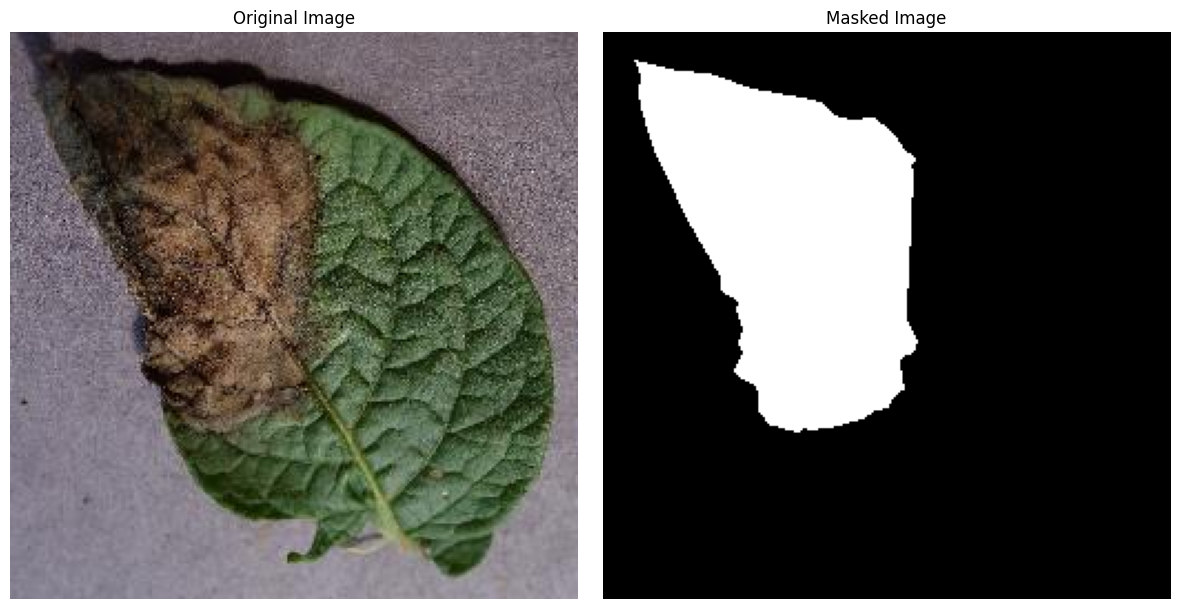

In [35]:
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import os

# The image_dir and mask_dir are already defined in previous cells
# image_dir = "/content/crop_disease_dataset/train"
# mask_dir = "/content/crop_disease_dataset/train_lesion_masks"

# Get a list of mask files from the mask_dir
# Ensure this directory actually contains files, as it should from previous cell execution
mask_files = os.listdir(mask_dir)
mask_files = [f for f in mask_files if f.endswith(".png")] # filter for png files

if not mask_files:
    print(f"No mask files found in {mask_dir}. Please ensure masks were generated correctly.")
else:
    # Pick the first mask file to display
    mask_file = mask_files[0]
    mask_path = os.path.join(mask_dir, mask_file)

    # The corresponding image file will have the same base name but with a .jpg extension
    image_base_name = os.path.splitext(mask_file)[0]
    image_file = image_base_name + ".jpg" # Assuming original images are .jpg
    image_path = os.path.join(image_dir, image_file)

    # Check if the image actually exists before trying to open it
    if not os.path.exists(image_path):
        print(f"Error: Corresponding image not found at {image_path}. "
              "Please verify the image_dir and file naming convention.")
    else:
        image = np.array(Image.open(image_path).convert("RGB"))
        mask = np.array(Image.open(mask_path))

        plt.figure(figsize=(12, 6))

        plt.subplot(1, 2, 1)
        plt.imshow(image)
        plt.title("Original Image")
        plt.axis("off")

        plt.subplot(1, 2, 2)
        plt.imshow(mask, cmap="gray") # Mask is grayscale
        plt.title("Masked Image")
        plt.axis("off")

        plt.tight_layout()
        plt.show()

In [36]:
import os
import numpy as np
from PIL import Image
from pycocotools.coco import COCO


TARGET_CATEGORY_ID = 7


def create_lesion_masks(split):

    json_path = f"/content/crop_disease_dataset/{split}/_annotations.coco.json"
    mask_dir = f"/content/crop_disease_dataset/{split}_lesion_masks"

    os.makedirs(mask_dir, exist_ok=True)

    coco = COCO(json_path)

    image_ids = coco.getImgIds(catIds=[TARGET_CATEGORY_ID])

    print(f"\n{split.upper()}")
    print("Potato Late Blight images:", len(image_ids))

    total_annotations = 0

    for image_id in image_ids:

        img_info = coco.loadImgs(image_id)[0]

        width = img_info["width"]
        height = img_info["height"]
        file_name = img_info["file_name"]

        # Empty binary lesion mask
        final_mask = np.zeros((height, width), dtype=np.uint8)

        # Only category 7 annotations for this image
        ann_ids = coco.getAnnIds(
            imgIds=[image_id],
            catIds=[TARGET_CATEGORY_ID]
        )

        anns = coco.loadAnns(ann_ids)
        total_annotations += len(anns)

        # Combine all lesion polygons
        for ann in anns:
            ann_mask = coco.annToMask(ann)
            final_mask[ann_mask > 0] = 255

        # Save as PNG
        base_name = os.path.splitext(file_name)[0]
        mask_path = os.path.join(mask_dir, base_name + ".png")

        Image.fromarray(final_mask).save(mask_path)

    print("Annotations converted:", total_annotations)
    print("Masks saved to:", mask_dir)


# Create masks
create_lesion_masks("train")
create_lesion_masks("valid")

loading annotations into memory...
Done (t=0.24s)
creating index...
index created!

TRAIN
Potato Late Blight images: 493
Annotations converted: 1829
Masks saved to: /content/crop_disease_dataset/train_lesion_masks
loading annotations into memory...
Done (t=0.04s)
creating index...
index created!

VALID
Potato Late Blight images: 74
Annotations converted: 265
Masks saved to: /content/crop_disease_dataset/valid_lesion_masks


# **Count All**

In [37]:
from pycocotools.coco import COCO
import os

base = "/content/crop_disease_dataset"

for split in ["train", "valid"]:
    json_path = os.path.join(base, split, "_annotations.coco.json")
    coco = COCO(json_path)

    print(f"\n{split.upper()}")

    for cat_id, name in [
        (6, "Potato Healthy"),
        (7, "Potato Late Blight")
    ]:
        image_ids = coco.getImgIds(catIds=[cat_id])
        print(f"{name}: {len(image_ids)}")

loading annotations into memory...
Done (t=0.34s)
creating index...
index created!

TRAIN
Potato Healthy: 516
Potato Late Blight: 493
loading annotations into memory...
Done (t=0.07s)
creating index...
index created!

VALID
Potato Healthy: 75
Potato Late Blight: 74


# **XYZ**

In [38]:
import os
import shutil
import random
import numpy as np
from PIL import Image
from pycocotools.coco import COCO

# ============================================================
# PATHS
# ============================================================

SRC = "/content/crop_disease_dataset"
OUT = "/content/Potato_Severity_Dataset"

TRAIN_JSON = os.path.join(SRC, "train", "_annotations.coco.json")
VALID_JSON = os.path.join(SRC, "valid", "_annotations.coco.json")

# Existing lesion-mask folders
TRAIN_MASK_DIR = os.path.join(SRC, "train_lesion_masks")
VALID_MASK_DIR = os.path.join(SRC, "valid_lesion_masks")

# Potato categories
HEALTHY_ID = 6
LATE_BLIGHT_ID = 7

RANDOM_SEED = 42

# ============================================================
# CREATE OUTPUT STRUCTURE
# ============================================================

for split in ["train", "valid", "test"]:
    os.makedirs(os.path.join(OUT, split, "images"), exist_ok=True)
    os.makedirs(os.path.join(OUT, split, "lesion_masks"), exist_ok=True)

# ============================================================
# LOAD ORIGINAL COCO JSONS
# ============================================================

coco_train = COCO(TRAIN_JSON)
coco_valid = COCO(VALID_JSON)

# ============================================================
# COLLECT IMAGE INFORMATION
# ============================================================

records = []

def collect_records(coco, split_name):

    for category_id, class_name in [
        (HEALTHY_ID, "Potato Healthy"),
        (LATE_BLIGHT_ID, "Potato Late Blight")
    ]:

        image_ids = coco.getImgIds(catIds=[category_id])
        images = coco.loadImgs(image_ids)

        for img in images:

            records.append({
                "source_split": split_name,
                "category_id": category_id,
                "class_name": class_name,
                "file_name": img["file_name"],
                "width": img["width"],
                "height": img["height"],
                "image_id": img["id"]
            })


collect_records(coco_train, "train")
collect_records(coco_valid, "valid")

print("Total records:", len(records))

# ============================================================
# REMOVE DUPLICATE FILES, JUST IN CASE
# ============================================================

unique_records = {}

for r in records:
    key = r["file_name"]

    if key not in unique_records:
        unique_records[key] = r
    else:
        print("DUPLICATE FILE:", key)

records = list(unique_records.values())

print("Unique records:", len(records))

# ============================================================
# SEPARATE BY CLASS
# ============================================================

healthy = [
    r for r in records
    if r["category_id"] == HEALTHY_ID
]

late_blight = [
    r for r in records
    if r["category_id"] == LATE_BLIGHT_ID
]

print("\nHealthy:", len(healthy))
print("Late Blight:", len(late_blight))

# ============================================================
# STRATIFIED SPLIT FUNCTION
# ============================================================

random.seed(RANDOM_SEED)

def split_class(items):

    items = items.copy()
    random.shuffle(items)

    n = len(items)

    n_train = round(n * 0.80)
    n_valid = round(n * 0.10)

    train_items = items[:n_train]
    valid_items = items[n_train:n_train + n_valid]
    test_items = items[n_train + n_valid:]

    return train_items, valid_items, test_items


healthy_train, healthy_valid, healthy_test = split_class(healthy)
lb_train, lb_valid, lb_test = split_class(late_blight)

# ============================================================
# COMBINE CLASSES
# ============================================================

splits = {
    "train": healthy_train + lb_train,
    "valid": healthy_valid + lb_valid,
    "test": healthy_test + lb_test
}

# Shuffle each final split
for split in splits:
    random.shuffle(splits[split])

# ============================================================
# PRINT FINAL COUNTS
# ============================================================

print("\nFINAL SPLIT")

for split, items in splits.items():

    n_healthy = sum(
        1 for r in items
        if r["category_id"] == HEALTHY_ID
    )

    n_lb = sum(
        1 for r in items
        if r["category_id"] == LATE_BLIGHT_ID
    )

    print(
        f"{split.upper():5s} | "
        f"Healthy={n_healthy:3d} | "
        f"Late Blight={n_lb:3d} | "
        f"Total={len(items):3d}"
    )

# ============================================================
# COPY IMAGES + CREATE/COPY MASKS
# ============================================================

def get_source_image_path(record):

    return os.path.join(
        SRC,
        record["source_split"],
        record["file_name"]
    )


def get_source_mask_path(record):

    base = os.path.splitext(record["file_name"])[0]
    mask_name = base + ".png"

    if record["source_split"] == "train":
        mask_dir = TRAIN_MASK_DIR
    else:
        mask_dir = VALID_MASK_DIR

    return os.path.join(mask_dir, mask_name)


for split, items in splits.items():

    print(f"\nProcessing {split}...")

    for record in items:

        file_name = record["file_name"]
        image_src = get_source_image_path(record)

        image_dst = os.path.join(
            OUT,
            split,
            "images",
            file_name
        )

        mask_name = os.path.splitext(file_name)[0] + ".png"

        mask_dst = os.path.join(
            OUT,
            split,
            "lesion_masks",
            mask_name
        )

        # --------------------------------------------
        # Check source image
        # --------------------------------------------

        if not os.path.exists(image_src):
            raise FileNotFoundError(
                f"Missing image: {image_src}"
            )

        # Copy image
        shutil.copy2(image_src, image_dst)

        # --------------------------------------------
        # POTATO HEALTHY
        # --------------------------------------------

        if record["category_id"] == HEALTHY_ID:

            # Healthy = no disease lesion
            empty_mask = np.zeros(
                (record["height"], record["width"]),
                dtype=np.uint8
            )

            Image.fromarray(empty_mask).save(mask_dst)

        # --------------------------------------------
        # POTATO LATE BLIGHT
        # --------------------------------------------

        elif record["category_id"] == LATE_BLIGHT_ID:

            mask_src = get_source_mask_path(record)

            if not os.path.exists(mask_src):
                raise FileNotFoundError(
                    f"Missing lesion mask: {mask_src}"
                )

            shutil.copy2(mask_src, mask_dst)

print("\nDataset creation complete.")

loading annotations into memory...
Done (t=0.32s)
creating index...
index created!
loading annotations into memory...
Done (t=0.07s)
creating index...
index created!
Total records: 1158
Unique records: 1158

Healthy: 591
Late Blight: 567

FINAL SPLIT
TRAIN | Healthy=473 | Late Blight=454 | Total=927
VALID | Healthy= 59 | Late Blight= 57 | Total=116
TEST  | Healthy= 59 | Late Blight= 56 | Total=115

Processing train...

Processing valid...

Processing test...

Dataset creation complete.


# **final counts verify**

In [39]:
def count_images(folder):
    return len([
        f for f in os.listdir(folder)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ])


def count_masks(folder):
    return len([
        f for f in os.listdir(folder)
        if f.lower().endswith(".png")
    ])


for split in ["train", "valid", "test"]:

    img_dir = os.path.join(OUT, split, "images")
    mask_dir = os.path.join(OUT, split, "lesion_masks")

    print(
        f"{split.upper():5s} | "
        f"Images={count_images(img_dir):3d} | "
        f"Masks={count_masks(mask_dir):3d}"
    )

TRAIN | Images=927 | Masks=927
VALID | Images=116 | Masks=116
TEST  | Images=115 | Masks=115


# **Image-mask matching verify**

In [40]:
for split in ["train", "valid", "test"]:

    image_dir = os.path.join(OUT, split, "images")
    mask_dir = os.path.join(OUT, split, "lesion_masks")

    image_stems = {
        os.path.splitext(f)[0]
        for f in os.listdir(image_dir)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    }

    mask_stems = {
        os.path.splitext(f)[0]
        for f in os.listdir(mask_dir)
        if f.lower().endswith(".png")
    }

    missing_masks = image_stems - mask_stems
    orphan_masks = mask_stems - image_stems

    print(f"\n{split.upper()}")
    print("Missing masks:", len(missing_masks))
    print("Orphan masks:", len(orphan_masks))


TRAIN
Missing masks: 0
Orphan masks: 0

VALID
Missing masks: 0
Orphan masks: 0

TEST
Missing masks: 0
Orphan masks: 0


# **ealthy mask সত্যিই empty কিনা verify করো**

In [41]:
healthy_test = [
    r for r in splits["test"]
    if r["category_id"] == HEALTHY_ID
]

sample = healthy_test[0]

mask_name = os.path.splitext(sample["file_name"])[0] + ".png"

mask_path = os.path.join(
    OUT,
    "test",
    "lesion_masks",
    mask_name
)

mask = np.array(Image.open(mask_path))

print("Unique mask values:", np.unique(mask))
print("Lesion pixels:", np.sum(mask > 0))

Unique mask values: [0]
Lesion pixels: 0


# ***Late Blight mask visually check করো***

In [44]:
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

lb_sample = [
    r for r in splits["test"]
    if r["category_id"] == LATE_BLIGHT_ID
][0]

image_name = lb_sample["file_name"]

image_path = os.path.join(
    OUT, "test", "images", image_name
)

mask_path = os.path.join(
    OUT,
    "test",
    "lesion_masks",
    os.path.splitext(image_name)[0] + ".png"
)

print("Image:", image_path)
print("Mask :", mask_path)

print("\nImage exists:", os.path.exists(image_path))
print("Mask exists :", os.path.exists(mask_path))

if os.path.exists(mask_path):
    mask = np.array(Image.open(mask_path))

    print("\nMask shape:", mask.shape)
    print("Unique values:", np.unique(mask))
    print("Mask min:", mask.min())
    print("Mask max:", mask.max())
    print("Lesion pixels:", np.sum(mask > 0))
    print("Total pixels:", mask.size)
    print("Lesion %:", 100 * np.mean(mask > 0))

Image: /content/Potato_Severity_Dataset/test/images/110_Potato_Late_Blight_train_JPG.rf.ca23313c6fcd3450ae3af6ccb28597ee.jpg
Mask : /content/Potato_Severity_Dataset/test/lesion_masks/110_Potato_Late_Blight_train_JPG.rf.ca23313c6fcd3450ae3af6ccb28597ee.png

Image exists: True
Mask exists : True

Mask shape: (256, 256)
Unique values: [  0 255]
Mask min: 0
Mask max: 255
Lesion pixels: 2216
Total pixels: 65536
Lesion %: 3.38134765625


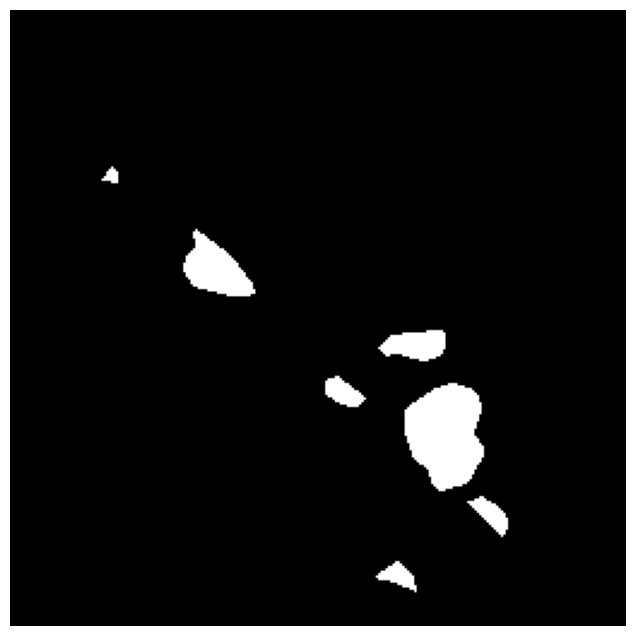

In [45]:
plt.figure(figsize=(8, 8))
plt.imshow(mask, cmap="gray")
plt.axis("off")
plt.show()

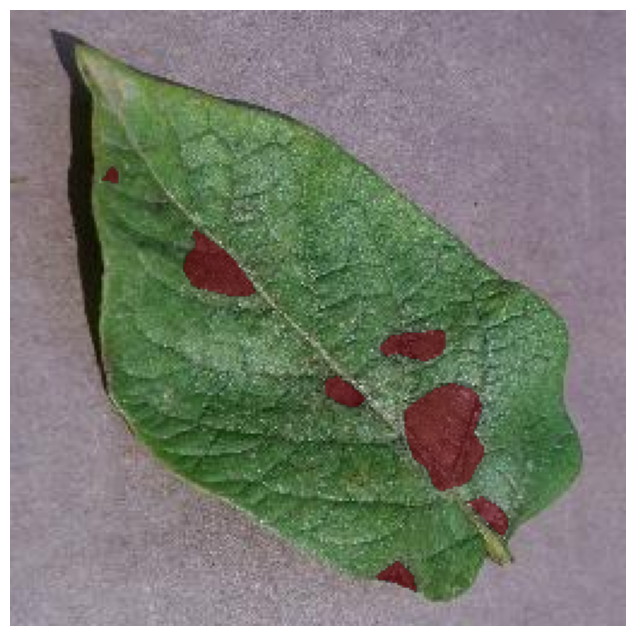

In [46]:
image = np.array(
    Image.open(image_path).convert("RGB")
)

plt.figure(figsize=(8, 8))

plt.imshow(image)

# Only show non-zero lesion pixels
lesion_overlay = np.ma.masked_equal(mask, 0)

plt.imshow(
    lesion_overlay,
    alpha=0.6,
    cmap="Reds",
    vmin=1,
    vmax=255
)

plt.axis("off")
plt.show()

# **Cell 1 — Paths and setup**

In [48]:
import os
import shutil
import random
import numpy as np
import pandas as pd

from PIL import Image
from pycocotools.coco import COCO
from sklearn.model_selection import train_test_split

# =========================================================
# SOURCE DATASET
# =========================================================

SRC = "/content/crop_disease_dataset"

# Existing folders containing masks
TRAIN_MASK_SRC = os.path.join(SRC, "train_lesion_masks")
VALID_MASK_SRC = os.path.join(SRC, "valid_lesion_masks")

# =========================================================
# FINAL DATASET
# =========================================================

OUT = "/content/Potato_Severity_Dataset"

# Remove old output if it exists
if os.path.exists(OUT):
    shutil.rmtree(OUT)

# Create final folder structure
for split in ["train", "valid", "test"]:
    os.makedirs(os.path.join(OUT, split, "images"), exist_ok=True)
    os.makedirs(os.path.join(OUT, split, "lesion_masks"), exist_ok=True)

print("Final dataset folder created:")
print(OUT)

Final dataset folder created:
/content/Potato_Severity_Dataset


# **Cell 2 — Read ONLY Potato Healthy + Late Blight**

In [49]:
HEALTHY_ID = 6
LATE_BLIGHT_ID = 7

records = []

for source_split in ["train", "valid"]:

    json_path = os.path.join(
        SRC,
        source_split,
        "_annotations.coco.json"
    )

    coco = COCO(json_path)

    for category_id in [HEALTHY_ID, LATE_BLIGHT_ID]:

        image_ids = coco.getImgIds(
            catIds=[category_id]
        )

        images = coco.loadImgs(image_ids)

        for img in images:

            records.append({
                "file_name": img["file_name"],
                "width": img["width"],
                "height": img["height"],
                "category_id": category_id,
                "class_name": (
                    "Potato Healthy"
                    if category_id == HEALTHY_ID
                    else "Potato Late Blight"
                ),
                "source_split": source_split
            })

df = pd.DataFrame(records)

# Check duplicate filenames
duplicates = df[df.duplicated("file_name", keep=False)]

print("Total records:", len(df))
print("\nClass distribution:")
print(df["class_name"].value_counts())

print("\nDuplicates:", len(duplicates))

loading annotations into memory...
Done (t=0.29s)
creating index...
index created!
loading annotations into memory...
Done (t=0.06s)
creating index...
index created!
Total records: 1158

Class distribution:
class_name
Potato Healthy        591
Potato Late Blight    567
Name: count, dtype: int64

Duplicates: 0


# **Cell 3 — 80/10/10 stratified split**

In [50]:
RANDOM_SEED = 42

train_df, temp_df = train_test_split(
    df,
    test_size=0.20,
    stratify=df["category_id"],
    random_state=RANDOM_SEED
)

valid_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["category_id"],
    random_state=RANDOM_SEED
)

train_df = train_df.copy()
valid_df = valid_df.copy()
test_df = test_df.copy()

train_df["final_split"] = "train"
valid_df["final_split"] = "valid"
test_df["final_split"] = "test"

splits_df = pd.concat(
    [train_df, valid_df, test_df],
    ignore_index=True
)

print("TRAIN")
print(train_df["class_name"].value_counts())
print("Total:", len(train_df))

print("\nVALID")
print(valid_df["class_name"].value_counts())
print("Total:", len(valid_df))

print("\nTEST")
print(test_df["class_name"].value_counts())
print("Total:", len(test_df))

TRAIN
class_name
Potato Healthy        473
Potato Late Blight    453
Name: count, dtype: int64
Total: 926

VALID
class_name
Potato Healthy        59
Potato Late Blight    57
Name: count, dtype: int64
Total: 116

TEST
class_name
Potato Healthy        59
Potato Late Blight    57
Name: count, dtype: int64
Total: 116


# **Cell 4 — Copy images + create/copy lesion masks**

In [51]:
import os
import shutil
import numpy as np
from PIL import Image


def copy_split(split_df, final_split):

    image_out = os.path.join(
        OUT, final_split, "images"
    )

    mask_out = os.path.join(
        OUT, final_split, "lesion_masks"
    )

    copied = 0
    created_empty = 0
    missing_masks = []

    for _, row in split_df.iterrows():

        file_name = row["file_name"]
        source_split = row["source_split"]
        category_id = row["category_id"]

        # -----------------------------------------
        # Source image
        # -----------------------------------------

        src_image = os.path.join(
            SRC,
            source_split,
            file_name
        )

        dst_image = os.path.join(
            image_out,
            file_name
        )

        if not os.path.exists(src_image):

            print("MISSING IMAGE:", src_image)
            continue

        shutil.copy2(
            src_image,
            dst_image
        )

        # -----------------------------------------
        # Target mask filename
        # -----------------------------------------

        mask_name = (
            os.path.splitext(file_name)[0]
            + ".png"
        )

        dst_mask = os.path.join(
            mask_out,
            mask_name
        )

        # -----------------------------------------
        # Healthy → empty lesion mask
        # -----------------------------------------

        if category_id == HEALTHY_ID:

            empty_mask = np.zeros(
                (int(row["height"]), int(row["width"])),
                dtype=np.uint8
            )

            Image.fromarray(
                empty_mask
            ).save(dst_mask)

            created_empty += 1

        # -----------------------------------------
        # Late Blight → existing lesion mask
        # -----------------------------------------

        elif category_id == LATE_BLIGHT_ID:

            src_mask_dir = (
                TRAIN_MASK_SRC
                if source_split == "train"
                else VALID_MASK_SRC
            )

            src_mask = os.path.join(
                src_mask_dir,
                mask_name
            )

            if not os.path.exists(src_mask):

                missing_masks.append({
                    "image": file_name,
                    "source_split": source_split,
                    "expected_mask": src_mask
                })

                continue

            shutil.copy2(
                src_mask,
                dst_mask
            )

        copied += 1

    print(f"\n{final_split.upper()}")
    print("Images copied:", copied)
    print("Healthy empty masks:", created_empty)
    print("Missing masks:", len(missing_masks))

    if missing_masks:
        print("\nFirst missing masks:")
        for item in missing_masks[:10]:
            print(item)

    return missing_masks


train_missing = copy_split(train_df, "train")
valid_missing = copy_split(valid_df, "valid")
test_missing = copy_split(test_df, "test")


TRAIN
Images copied: 926
Healthy empty masks: 473
Missing masks: 0

VALID
Images copied: 116
Healthy empty masks: 59
Missing masks: 0

TEST
Images copied: 116
Healthy empty masks: 59
Missing masks: 0


# **Cell 5 — Save the split manifest**

In [52]:
manifest_path = os.path.join(
    OUT,
    "manifest.csv"
)

splits_df[
    [
        "file_name",
        "width",
        "height",
        "category_id",
        "class_name",
        "source_split",
        "final_split"
    ]
].to_csv(
    manifest_path,
    index=False
)

print("Manifest saved:")
print(manifest_path)

Manifest saved:
/content/Potato_Severity_Dataset/manifest.csv


# **Cell 6 — Verify image ↔ mask pairing**

In [53]:
def verify_pairing(split):

    image_dir = os.path.join(
        OUT, split, "images"
    )

    mask_dir = os.path.join(
        OUT, split, "lesion_masks"
    )

    image_names = {
        os.path.splitext(f)[0]
        for f in os.listdir(image_dir)
        if f.lower().endswith(
            (".jpg", ".jpeg", ".png")
        )
    }

    mask_names = {
        os.path.splitext(f)[0]
        for f in os.listdir(mask_dir)
        if f.lower().endswith(".png")
    }

    images_without_masks = image_names - mask_names
    masks_without_images = mask_names - image_names

    print(f"\n{split.upper()}")
    print("Images:", len(image_names))
    print("Masks :", len(mask_names))
    print("Images without mask:", len(images_without_masks))
    print("Masks without image:", len(masks_without_images))

    return (
        images_without_masks,
        masks_without_images
    )


for split in ["train", "valid", "test"]:
    verify_pairing(split)


TRAIN
Images: 926
Masks : 926
Images without mask: 0
Masks without image: 0

VALID
Images: 116
Masks : 116
Images without mask: 0
Masks without image: 0

TEST
Images: 116
Masks : 116
Images without mask: 0
Masks without image: 0


# **Cell 7 — Verify class distribution**

In [54]:
for split in ["train", "valid", "test"]:

    temp = splits_df[
        splits_df["final_split"] == split
    ]

    print(f"\n{split.upper()}")
    print(temp["class_name"].value_counts())


TRAIN
class_name
Potato Healthy        473
Potato Late Blight    453
Name: count, dtype: int64

VALID
class_name
Potato Healthy        59
Potato Late Blight    57
Name: count, dtype: int64

TEST
class_name
Potato Healthy        59
Potato Late Blight    57
Name: count, dtype: int64


# **Cell 8 — Verify Healthy masks are actually empty**

In [55]:
for split in ["train", "valid", "test"]:

    subset = splits_df[
        (splits_df["final_split"] == split) &
        (splits_df["category_id"] == HEALTHY_ID)
    ]

    bad_masks = []

    for _, row in subset.iterrows():

        mask_name = (
            os.path.splitext(row["file_name"])[0]
            + ".png"
        )

        mask_path = os.path.join(
            OUT,
            split,
            "lesion_masks",
            mask_name
        )

        mask = np.array(
            Image.open(mask_path)
        )

        if np.any(mask > 0):
            bad_masks.append(row["file_name"])

    print(
        split,
        "healthy masks with lesion pixels:",
        len(bad_masks)
    )

train healthy masks with lesion pixels: 0
valid healthy masks with lesion pixels: 0
test healthy masks with lesion pixels: 0


# **Cell 9 — Verify Late Blight masks are not empty**

In [56]:
for split in ["train", "valid", "test"]:

    subset = splits_df[
        (splits_df["final_split"] == split) &
        (splits_df["category_id"] == LATE_BLIGHT_ID)
    ]

    empty_masks = []

    for _, row in subset.iterrows():

        mask_name = (
            os.path.splitext(row["file_name"])[0]
            + ".png"
        )

        mask_path = os.path.join(
            OUT,
            split,
            "lesion_masks",
            mask_name
        )

        mask = np.array(
            Image.open(mask_path)
        )

        if not np.any(mask > 0):
            empty_masks.append(row["file_name"])

    print(
        split,
        "Late Blight masks that are empty:",
        len(empty_masks)
    )

train Late Blight masks that are empty: 0
valid Late Blight masks that are empty: 0
test Late Blight masks that are empty: 0


# **Cell 10 — Test overlay**

Image shape: (256, 256, 3)
Mask shape : (256, 256)
Mask values: [  0 255]
Lesion pixels: 4607


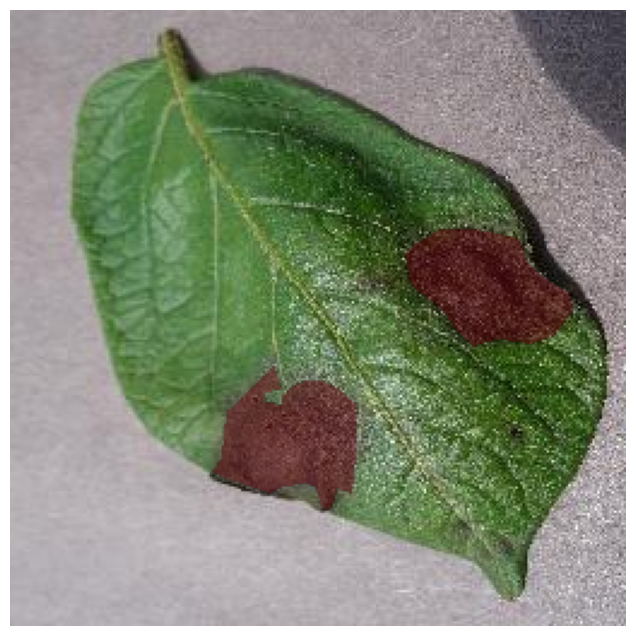

In [57]:
import matplotlib.pyplot as plt

lb_sample = test_df[
    test_df["category_id"] == LATE_BLIGHT_ID
].iloc[0]

image_path = os.path.join(
    OUT,
    "test",
    "images",
    lb_sample["file_name"]
)

mask_path = os.path.join(
    OUT,
    "test",
    "lesion_masks",
    os.path.splitext(
        lb_sample["file_name"]
    )[0] + ".png"
)

image = np.array(
    Image.open(image_path).convert("RGB")
)

mask = np.array(
    Image.open(mask_path)
)

print("Image shape:", image.shape)
print("Mask shape :", mask.shape)
print("Mask values:", np.unique(mask))
print("Lesion pixels:", np.sum(mask > 0))

plt.figure(figsize=(8, 8))

plt.imshow(image)

plt.imshow(
    np.ma.masked_equal(mask, 0),
    alpha=0.45,
    cmap="Reds",
    vmin=1,
    vmax=255
)

plt.axis("off")
plt.show()

# **Cell 11 — Save final ZIP**

In [58]:
import shutil

zip_file = shutil.make_archive(
    "/content/Potato_Severity_Dataset",
    "zip",
    OUT
)

print("ZIP created:")
print(zip_file)

ZIP created:
/content/Potato_Severity_Dataset.zip


In [59]:
drive_zip = "/content/drive/MyDrive/Potato_Severity_Dataset.zip"

shutil.copy2(
    zip_file,
    drive_zip
)

print("Saved to Drive:")
print(drive_zip)

Saved to Drive:
/content/drive/MyDrive/Potato_Severity_Dataset.zip
